# check frames

In [8]:
import os
import pandas as pd
from fastai.vision.all import *

df = pd.read_csv("labels.csv")
print(f"Total frames: {len(df)}")
print(f"Moisture levels: {df['moisture'].unique()}")
print(df.head(10))

Total frames: 2505
Moisture levels: [ 0  1 10 12 14 16  2  4  6  8]
                   filename  moisture
0  0%_cropped_frame0000.jpg         0
1  0%_cropped_frame0001.jpg         0
2  0%_cropped_frame0002.jpg         0
3  0%_cropped_frame0003.jpg         0
4  0%_cropped_frame0004.jpg         0
5  0%_cropped_frame0005.jpg         0
6  0%_cropped_frame0006.jpg         0
7  0%_cropped_frame0007.jpg         0
8  0%_cropped_frame0008.jpg         0
9  0%_cropped_frame0009.jpg         0


c:\ProgramData\anaconda3\envs\regression\lib\site-packages\fastai\data\transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


<div></div>

SuggestedLRs(valley=0.0020892962347716093)

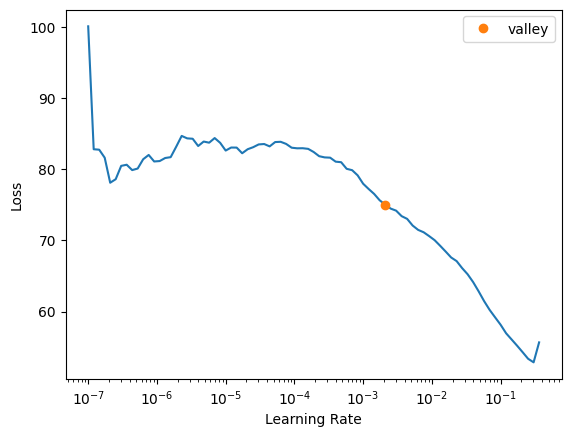

In [9]:
df = pd.read_csv("labels.csv")

dls = ImageDataLoaders.from_df(
    df,
    path="frames/",
    label_col="moisture",
    y_block=RegressionBlock,
    item_tfms=Resize(224),
    valid_pct=0.2          # uses 20% of frames for testing
)

learn = vision_learner(dls, resnet34, loss_func=MSELossFlat())
# learn.fine_tune(30)
# Find best learning rate first
learn.lr_find()

# Train

In [ ]:
learn.fine_tune(30, base_lr=1e-2)

In [7]:
preds, targets = learn.get_preds(with_input=False)

for i in range(10):
    predicted = preds[i].item()
    actual = targets[i].item()
    print(f"Predicted: {predicted:.1f}%  |  Actual: {actual:.1f}%  |  Error: {abs(predicted-actual):.1f}%")

Predicted: 2.6%  |  Actual: 8.0%  |  Error: 5.4%
Predicted: -1.0%  |  Actual: 6.0%  |  Error: 7.0%
Predicted: -4.1%  |  Actual: 1.0%  |  Error: 5.1%
Predicted: -4.9%  |  Actual: 1.0%  |  Error: 5.9%
Predicted: -4.8%  |  Actual: 2.0%  |  Error: 6.8%
Predicted: -5.0%  |  Actual: 1.0%  |  Error: 6.0%
Predicted: 6.4%  |  Actual: 14.0%  |  Error: 7.6%
Predicted: 3.5%  |  Actual: 12.0%  |  Error: 8.5%
Predicted: -3.6%  |  Actual: 2.0%  |  Error: 5.6%
Predicted: 1.4%  |  Actual: 8.0%  |  Error: 6.6%
